# Training the model on the imbalance dataset

C:\Users\DELL\AppData\Local\Temp\ipykernel_9932\3086165090.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


=== 1. CLASS IMBALANCE DISPLAY ===
Absolute Counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Percentage Distribution:
Churn
0    73.46%
1    26.54%
Name: proportion, dtype: object


C:\Users\DELL\AppData\Local\Temp\ipykernel_9932\3086165090.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Churn'], palette='Set2')


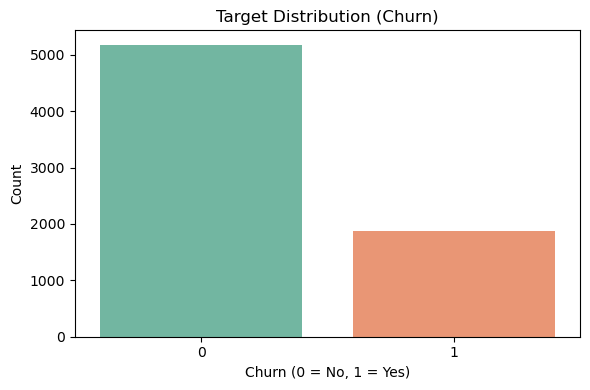


=== 2. IMBALANCED MODEL RESULTS ===
Accuracy:  0.8055
Precision: 0.6572
Recall:    0.5588
F1-Score:  0.604


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("=== 1. CLASS IMBALANCE DISPLAY ===")
print("Absolute Counts:")
print(df['Churn'].value_counts())
print("\nPercentage Distribution:")
print((df['Churn'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

plt.figure(figsize=(6, 4))
sns.countplot(x=df['Churn'], palette='Set2')
plt.title('Target Distribution (Churn)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore', sparse_output=False)), cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

model_imb = LogisticRegression(random_state=42, max_iter=1000)
model_imb.fit(X_train_prep, y_train)
y_pred_imb = model_imb.predict(X_test_prep)

print("\n=== 2. IMBALANCED MODEL RESULTS ===")
print("Accuracy: ", round(accuracy_score(y_test, y_pred_imb), 4))
print("Precision:", round(precision_score(y_test, y_pred_imb), 4))
print("Recall:   ", round(recall_score(y_test, y_pred_imb), 4))
print("F1-Score: ", round(f1_score(y_test, y_pred_imb), 4))

# Balancing the class using the undersampling and then training the model

In [3]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_tr_rus, y_tr_rus = rus.fit_resample(X_train_prep, y_train)

model_rus = LogisticRegression(random_state=42, max_iter=1000)
model_rus.fit(X_tr_rus, y_tr_rus)
y_pred_rus = model_rus.predict(X_test_prep)

print("=== 5. UNDERSAMPLED MODEL RESULTS ===")
print("Accuracy: ", round(accuracy_score(y_test, y_pred_rus), 4))
print("Precision:", round(precision_score(y_test, y_pred_rus), 4))
print("Recall:   ", round(recall_score(y_test, y_pred_rus), 4))
print("F1-Score: ", round(f1_score(y_test, y_pred_rus), 4))

final_comparison = pd.DataFrame([
    {
        'Model': 'Imbalanced Baseline',
        'Accuracy': accuracy_score(y_test, y_pred_imb),
        'Precision': precision_score(y_test, y_pred_imb),
        'Recall': recall_score(y_test, y_pred_imb),
        'F1-Score': f1_score(y_test, y_pred_imb)
    },
    {
        'Model': 'Random Undersampled',
        'Accuracy': accuracy_score(y_test, y_pred_rus),
        'Precision': precision_score(y_test, y_pred_rus),
        'Recall': recall_score(y_test, y_pred_rus),
        'F1-Score': f1_score(y_test, y_pred_rus)
    }
])

print("\n=== FINAL COMPARISON TABLE ===")
display(final_comparison)

=== 5. UNDERSAMPLED MODEL RESULTS ===
Accuracy:  0.7424
Precision: 0.5095
Recall:    0.7861
F1-Score:  0.6183

=== FINAL COMPARISON TABLE ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Imbalanced Baseline,0.805536,0.657233,0.558824,0.604046
1,Random Undersampled,0.742370,0.509532,0.786096,0.618297


### Why Accuracy is Misleading on Imbalanced Data

#### 1. The High Accuracy Trap
In an imbalanced dataset (where ~73.5% of customers stay and only ~26.5% churn), a dummy model that predicts "No Churn" for every single customer would automatically achieve an **Accuracy of ~73.5%**. 

The baseline model's score of **80.55%** sounds strong at first glance, but it is heavily inflated simply because the model easily correctly classifies the non-churn majority.

---

#### 2. Failure to Catch Minority Events (Low Recall)
Accuracy treats all predictions equally, masking severe failures in detecting the minority target class:

* **Imbalanced Baseline Recall:** `0.5588` (**55.88%**)  
  * *Meaning:* The baseline model misses **44.12%** of all actual churners.
* **Random Undersampled Recall:** `0.7861` (**78.61%**)  
  * *Meaning:* After undersampling, the model captures nearly **79%** of actual churners.

---

#### 3. Asymmetric Business Costs
In real-world applications like customer retention or fraud detection, the cost of errors is uneven:

* **False Negative (Costly):** Missing a churner means losing a customer and their future revenue permanently.
* **False Positive (Cheap):** Incorrectly flagging a non-churner might mean sending an unnecessary promotional email or discount code.

Relying on accuracy causes you to choose the Imbalanced Baseline, which lets nearly half of your churning customers slip away undetected.